<a href="https://colab.research.google.com/github/sikharamkarthik/car-sale-prediction/blob/main/crop_yield_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving crop_yield.csv to crop_yield.csv


In [5]:
import zipfile
import os

# The uploaded file is actually a zip file. We need to extract it first.
# The 'uploaded' dictionary contains the file content as bytes.
zip_content = uploaded['crop_yield.csv']

# Save the zip content to a temporary zip file
with open('temp_crop_yield.zip', 'wb') as f:
    f.write(zip_content)

# Extract the zip file
with zipfile.ZipFile('temp_crop_yield.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

# Find the actual CSV file name after extraction. Assuming there's one CSV.
# We can list the extracted files if needed to confirm.
extracted_files = os.listdir('.')
csv_file_name = None
for f_name in extracted_files:
    if f_name.endswith('.csv'):
        csv_file_name = f_name
        break

if csv_file_name:
    data = pd.read_csv(csv_file_name)
    print(f"Successfully loaded {csv_file_name} into DataFrame.")
    print(data.head())
else:
    print("No CSV file found in the extracted archive.")


Successfully loaded Crop_recommendation.csv into DataFrame.
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [8]:
data.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [9]:
data.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [10]:
data = data.dropna()

In [12]:
X = data[['rainfall','temperature','humidity']]
y = data['label']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform y_train to numerical labels
y_train_encoded = le.fit_transform(y_train)

model = LinearRegression()
model.fit(X_train, y_train_encoded)

LinearRegression()

In [16]:
predictions = model.predict(X_test)
print(predictions)

[10.68210565  9.40409605 10.38497809 11.00212997 11.02755628 12.74296712
  7.13649843 10.65468087 11.12400885 12.5004944  10.45539066 10.43487482
 11.92050435 12.74253863 12.29445482 10.41616247 11.17868562 11.49362833
 11.21832585 12.02927268 11.29255275 10.02992152 11.29980685 10.85965923
 11.22161304  6.89174725  7.00351521  7.07444978  9.51838824  7.74402911
 11.17833627 11.22573981 11.39669619 10.80258454  7.23940188  9.97351258
 10.59766125 11.20206899 11.84965821 11.30841957 11.23871146  7.00744112
 12.41615719 11.36948783 10.87669415  9.2145885   9.68180948 11.37890328
 11.29748305 10.16707886 10.56823431 10.77587085  9.37879612  9.39803822
  6.84580182 11.80890073 10.4143823  11.16819225 11.28859248  9.51147684
  8.93628318 10.38003084 11.5791147  11.79458931 11.54127408 10.28629543
 12.32701819 11.15255497 10.06560101  7.4358731  10.91160819 10.22202675
 11.70423355 10.37748815  9.20602438 10.16166118 11.67567665 11.83702811
  9.18215881 11.09999592 10.12467058 10.96446488 10

In [18]:
from sklearn.metrics import mean_squared_error

# Transform y_test using the already fitted LabelEncoder
y_test_encoded = le.transform(y_test)

print(mean_squared_error(y_test_encoded, predictions))

37.85710229762231


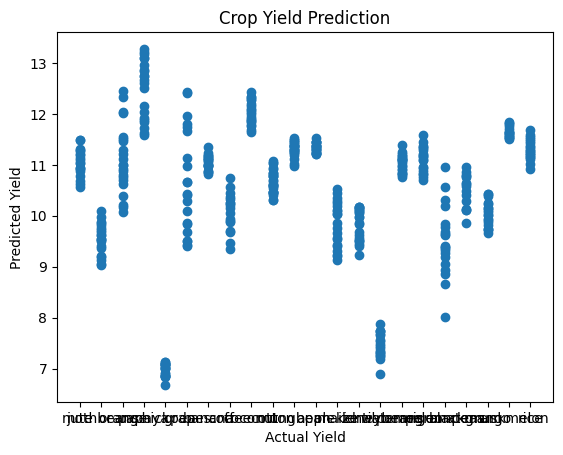

In [19]:
plt.scatter(y_test,predictions)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Crop Yield Prediction")
plt.show()